# **Basic EDA on Supermarket Sales Data**

--- 

###  *Loading Necessary Libraries*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### *Loading Dataset*

In [2]:
pd.set_option('display.max_columns', None)
df = pd.read_csv("supermarket_sales.csv",encoding='latin-1')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


### *Familiarizing with Dataset*

In [3]:
df.info() #to check the data types of the columns and to see if there are any missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [4]:
df.describe() #to get a statistical summary of the numerical columns in the dataset

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [5]:
df.size

17000

In [6]:
df.shape

(1000, 17)

In [7]:
df.isnull().sum() #to check for missing values in each column

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [8]:
df.duplicated().sum() #to check for duplicate rows in the dataset

0

---

### *Data Structuring*

In [9]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y') #to  convert the 'Date' column to datetime format

In [10]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M').dt.time #to convert the 'Time' column to datetime format and extract only the time component
df['Time'].head()

0    13:08:00
1    10:29:00
2    13:23:00
3    20:33:00
4    10:37:00
Name: Time, dtype: object

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Total                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

In [12]:
df.rename(columns={'Total': 'Total_Sales'}, inplace=True) #to rename the 'Total' column to 'Total_Sales' for better clarity

In [58]:
df['Rating'].mean() #to calculate the mean rating

6.9727

In [65]:
number_of_sales_by_month = pd.to_datetime(df['Date'],format='%Y-%m-%d').dt.month.value_counts().sort_index() #to count the number of sales in each month and sort the results by month
number_of_sales_by_month

Date
1    352
2    303
3    345
Name: count, dtype: int64

## *Data Handling*

### *Count of Sales Transactions by branch*

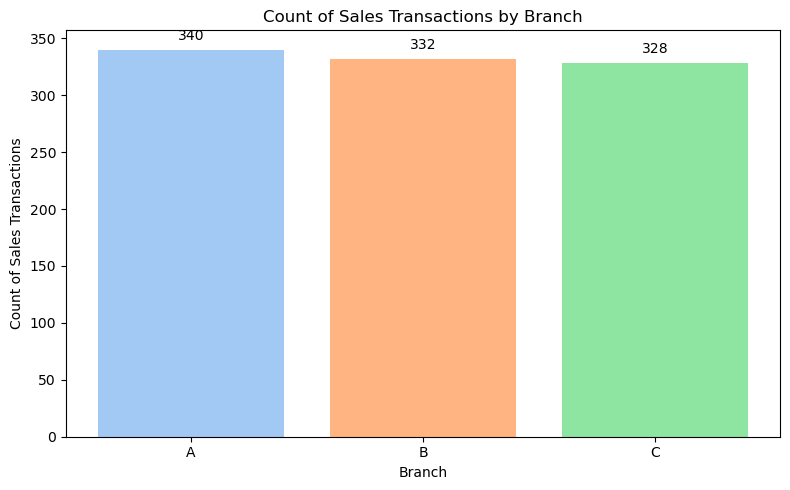

In [13]:
Count_of_Branch_by_Total_Sales = df.groupby('Branch')['Total_Sales'].count() #to count the number of sales transactions for each branch
fig, ax = plt.subplots(figsize=(8, 5)) #to create a figure and axis object for the bar chart with a specified size
ax.bar(Count_of_Branch_by_Total_Sales.index, Count_of_Branch_by_Total_Sales.values, color=sns.color_palette('pastel',len(Count_of_Branch_by_Total_Sales)))
ax.set_title('Count of Sales Transactions by Branch') #to set the title of the bar chart
for p in ax.patches: #to add the count values on top of each bar in the bar chart
    ax.annotate(str(p.get_height()), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black', 
                xytext=(0, 5), textcoords='offset points')
ax.set_xlabel('Branch') #to set the x and y axis labels
ax.set_ylabel('Count of Sales Transactions') #to set the x and y axis labels
plt.tight_layout() # to adjust the layout and prevent overlap of labels
plt.show() #to display the bar chart of the count of sales transactions by branch


### *Count of Sales By Product Line*

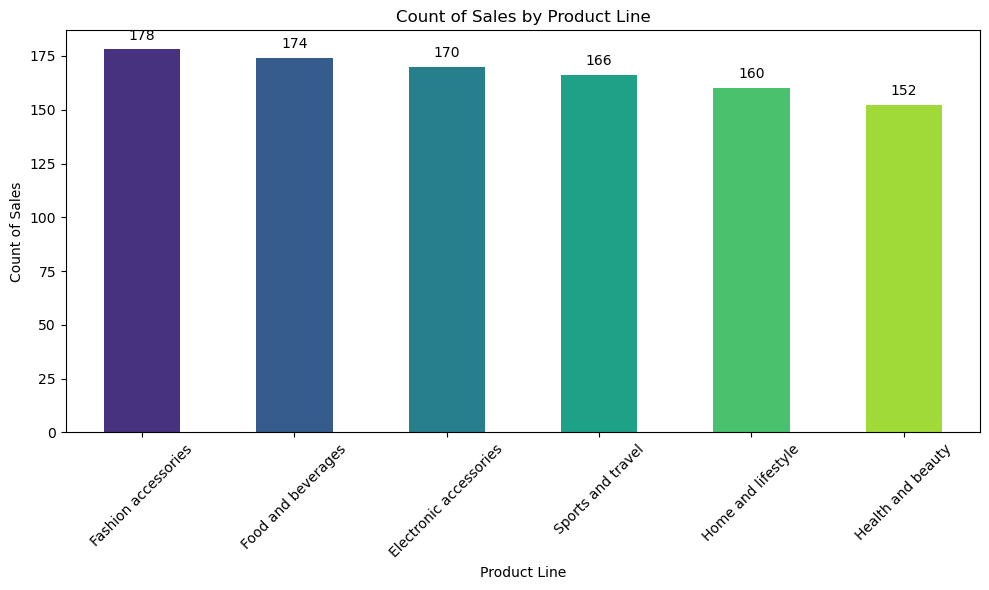

In [18]:
Count_of_Product_Line_by_Total_Sales = df.groupby('Product line')['Total_Sales'].count().sort_values(ascending=False)
ax = Count_of_Product_Line_by_Total_Sales.plot(kind='bar', figsize=(10, 6), color=sns.color_palette('viridis', len(Count_of_Product_Line_by_Total_Sales)))
for  p in ax.patches: #to add the count values on top of each bar in the bar chart
    ax.annotate(str(p.get_height()), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black', 
                xytext=(0, 5), textcoords='offset points')
plt.title('Count of Sales by Product Line') #to set the title of the bar chart
plt.xlabel('Product Line') #to set the x and y axis labels
plt.ylabel('Count of Sales') #to set the x and y axis labels
plt.xticks(rotation=45) #to rotate the x-axis labels for better readability
plt.tight_layout() # to adjust the layout and prevent overlap of labels
plt.show() #to display the bar chart of total sales by product line


### *Count of Sales by Customer type*

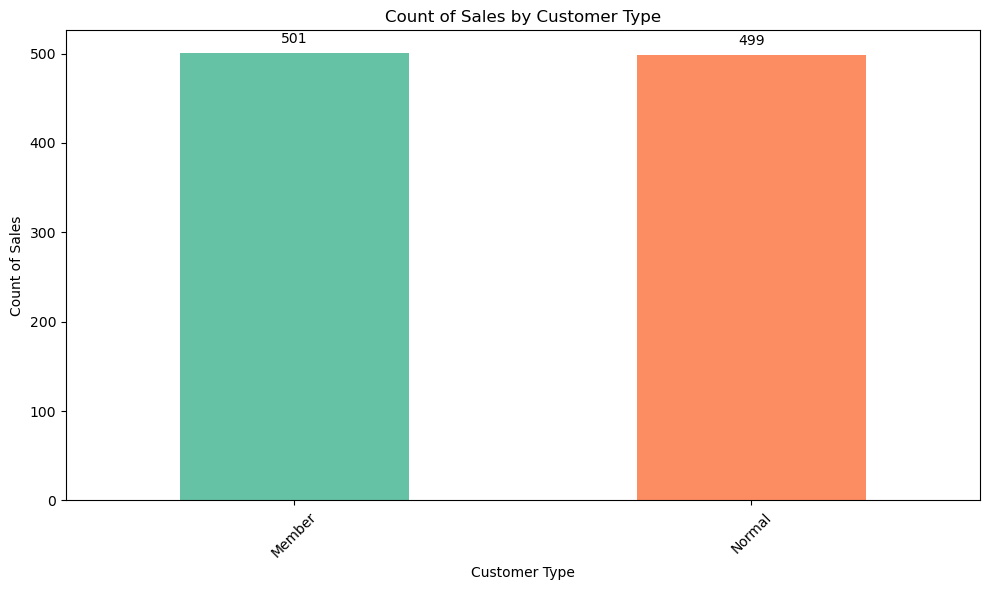

In [19]:
Count_of_Sales_by_Customer_Type = df.groupby('Customer type')['Total_Sales'].count().sort_values(ascending=False)
ax = Count_of_Sales_by_Customer_Type.plot(kind='bar', figsize=(10, 6), color=sns.color_palette('Set2', len(Count_of_Sales_by_Customer_Type)))
for  p in ax.patches: #to add the count values on top of each bar in the bar chart
    ax.annotate(str(p.get_height()), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black', 
                xytext=(0, 5), textcoords='offset points')
plt.title('Count of Sales by Customer Type') #to set the title of the bar chart
plt.xlabel('Customer Type') #to set the x and y axis labels
plt.ylabel('Count of Sales') #to set the x and y axis labels
plt.xticks(rotation=45) #to rotate the x-axis labels for better readability
plt.tight_layout() # to adjust the layout and prevent overlap of labels
plt.show() #to display the bar chart of total sales by product line


### *Count of Sales by Gender*

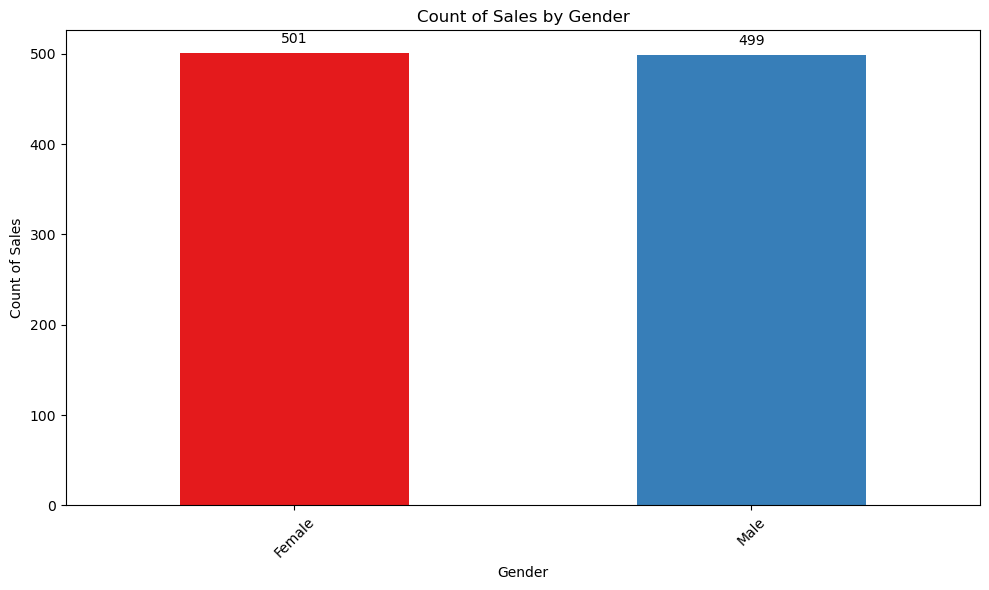

In [20]:
Count_of_Sales_by_Gender = df.groupby('Gender')['Total_Sales'].count().sort_values(ascending=False)
ax = Count_of_Sales_by_Gender.plot(kind='bar', figsize=(10, 6), color=sns.color_palette('Set1', len(Count_of_Sales_by_Gender)))
for  p in ax.patches: #to add the count values on top of each bar in the bar chart
    ax.annotate(str(p.get_height()), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black', 
                xytext=(0, 5), textcoords='offset points')
plt.title('Count of Sales by Gender') #to set the title of the bar chart
plt.xlabel('Gender') #to set the x and y axis labels
plt.ylabel('Count of Sales') #to set the x and y axis labels
plt.xticks(rotation=45) #to rotate the x-axis labels for better readability
plt.tight_layout() # to adjust the layout and prevent overlap of labels
plt.show() #to display the bar chart of total sales by product line


### *Busiest Hours of Day for Sales Transactions*

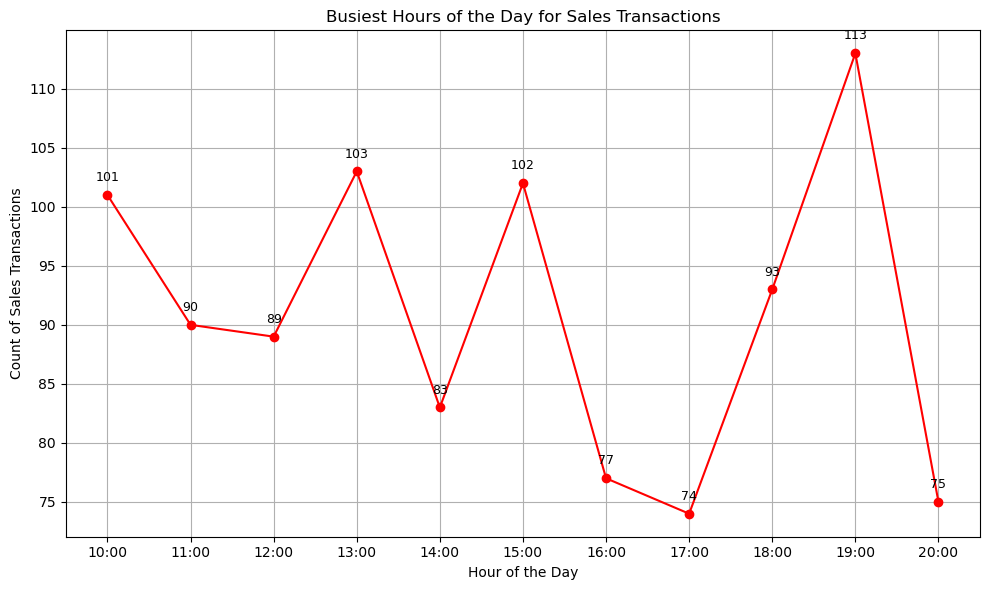

In [ ]:
Busiest_hours = pd.to_datetime(df['Time'],format='%H:%M:%S').dt.hour.value_counts().sort_index() #to count the number of sales transactions for each hour of the day and sort the results by hour
ax = Busiest_hours.plot(kind='line', marker='o', figsize=(10, 6), color='red') #to create a line plot of the busiest hours with markers for each point
for x, y in zip(Busiest_hours.index, Busiest_hours.values): #to add the count values on top of each point in the line plot
    ax.annotate(str(y), (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, color='black')
ax.set_title('Busiest Hours of the Day for Sales Transactions') #to set the title of the line plot
ax.set_xlabel('Hour of the Day') #to set the x and y axis labels   
ax.set_ylabel('Count of Sales Transactions') #to set the x and y axis labels
ax.set_xticks(Busiest_hours.index)
ax.set_xticklabels([f"{h}:00" for h in Busiest_hours.index])#to set the x-axis ticks to be the hours of the day
ax.grid() #to add a grid to the line plot for better readability
plt.tight_layout() # to adjust the layout and prevent overlap of labels
plt.show() #to display the line plot of the busiest hours of the day for sales transactions


### *Total Sales by Product Line and Branch(Heatmap)*

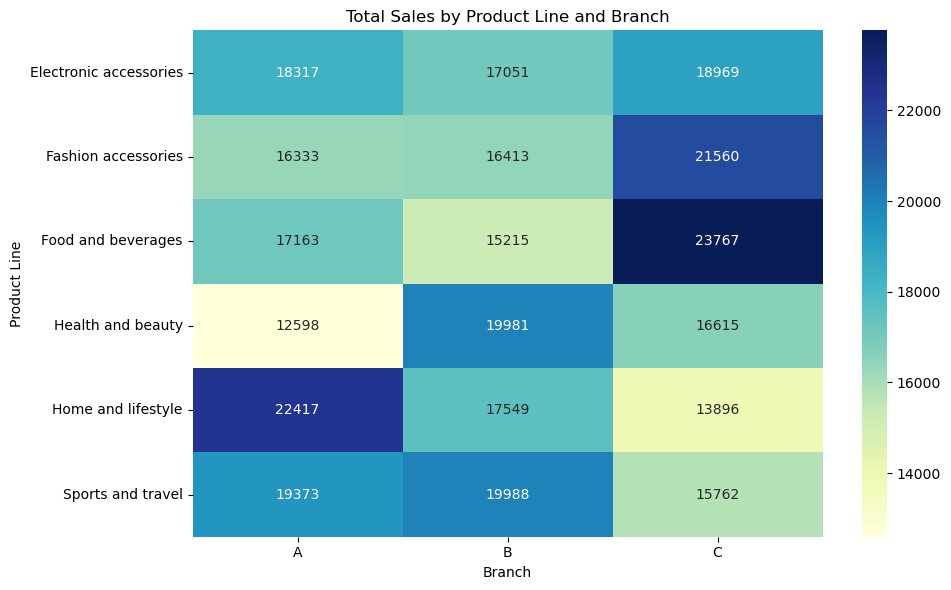

In [45]:
pivot = df.pivot_table(index='Product line', columns='Branch', values='Total_Sales', aggfunc='sum') #to create a pivot table that shows the total sales for each product line across different branches
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='YlGnBu') #to create a heatmap from the pivot table with annotations for the total sales values and a color map for better visualization
plt.title('Total Sales by Product Line and Branch') #to set the title of the heatmap
plt.xlabel('Branch') #to set the x and y axis labels
plt.ylabel('Product Line') #to set the x and y axis labels
plt.tight_layout() # to adjust the layout and prevent overlap of labels
plt.show() #to display the heatmap of total sales by product line and branch


### *Gross Margin per product line*

In [57]:
gross_margin_per_product_line = df.groupby('Product line').agg( #to calculate the gross margin for each product line by grouping the data by 'Product line' and aggregating the total sales and total cost of goods sold (COGS) for each product line
    Total_Sales=('Total_Sales', 'sum'), #to calculate the total sales for each product line by summing the 'Total_Sales' column
    Total_COGS=('cogs', 'sum') #to calculate the total cost of goods sold (COGS) for each product line by summing the 'cogs' column
)
gross_margin_per_product_line['Gross Margin (%)'] = (
    (gross_margin_per_product_line['Total_Sales'] -
     gross_margin_per_product_line['Total_COGS']) /
    gross_margin_per_product_line['Total_Sales'] * 100
)
gross_margin_per_product_line

,Total_Sales,Total_COGS,Gross Margin (%)
Product line,,,
Electronic accessories,54337.5315,51750.03,4.761905
Fashion accessories,54305.8950,51719.90,4.761905
Food and beverages,56144.8440,53471.28,4.761905
Health and beauty,49193.7390,46851.18,4.761905
Home and lifestyle,53861.9130,51297.06,4.761905
Sports and travel,55122.8265,52497.93,4.761905


---

## *Thank you for your considerations!*